In [56]:
from langgraph.graph import START,END,StateGraph
from typing import TypedDict

## Define State

In [57]:
from pydantic import BaseModel
class Temprature_state(BaseModel):
    temp_celsius: float
    temp_fahrenheit:  float = 0.0
    weather_status : str = ""

## Convert Temprature Function (First Node)

In [58]:
def convert_temp(state: Temprature_state)-> dict:

    celsius = state.temp_celsius

    #convert to fahrenheit
    return {"temp_fahrenheit": round((celsius * 9/5 +32),2)}



In [59]:
def label_weather(state: Temprature_state)-> Temprature_state:

    fahrenheit = state.temp_fahrenheit

    if fahrenheit < 50:
        state.weather_status = 'COLD'
    elif fahrenheit < 77:
       state.weather_status= 'MILD'
    elif fahrenheit < 95:
        state.weather_status= 'HOT'
    else: 
        state.weather_status = 'EXTREAM HOT'
    
    return state

## Define and Compile a Graph

In [60]:
#define a graph and provide state
graph = StateGraph(Temprature_state)

#add nodes to the graph 
graph.add_node('convert_temp',convert_temp)
graph.add_node('weather_status',label_weather)

#add the edges 
graph.add_edge(START,'convert_temp')
graph.add_edge('convert_temp','weather_status')
graph.add_edge('weather_status',END)

#compile the graph
workflow = graph.compile()

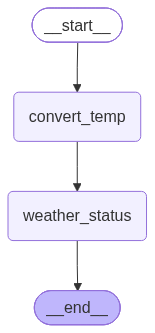

In [61]:
workflow

In [62]:
#execute the graph
initial_state = {'temp_celsius': 38.5}

final_state = workflow.invoke(initial_state)
final_state

{'temp_celsius': 38.5,
 'temp_fahrenheit': 101.3,
 'weather_status': 'EXTREAM HOT'}

## visualise the graph

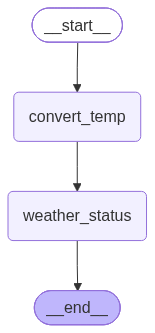

In [63]:
from IPython.display import Image

Image(workflow.get_graph().draw_mermaid_png())
